# AF5344 Group Project — Long Book Research & Selection

## Equity Long/Short Fund — HSI Universe

This notebook performs systematic screening of Hang Seng Index (HSI) constituents to select **10+ stocks for the Long Book**.

### Screening Criteria for Longs:
| Metric | Rationale |
|--------|----------|
| ROE | Efficient use of shareholder capital |
| Earnings Growth (YoY) | Growing companies tend to outperform |
| P/E Ratio | Avoids overpaying for growth |
| Debt/Equity |  Financial stability |
|profit margin|High-margin firms tend to outperform|
|12-month momentun| Price trend confirms strength |
| 6-Month Momentum | Price trend confirms strength |
| Dividend Yield | Additional return signal |
| Beta (β) | Moderate market sensitivity |
| Alpha (α) | Positive excess return vs benchmark |
| R-squared (R²) | Meaningful but not pure index tracking |

---
## 1. Setup & Install Dependencies

In [22]:
# Install required packages (run once)
#!pip install yfinance pandas numpy matplotlib seaborn scipy statsmodels --quiet

In [23]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print("All packages loaded successfully.")

All packages loaded successfully.


---
## 2. Define HSI Constituent Universe

Source: [Hang Seng Indexes](https://www.hsi.com.hk/eng/) — 88 constituents as of Feb 2026.

In [24]:
# HSI Constituents — Full 88-stock list (Feb 2026)
# Format: (Stock Code, Yahoo Ticker, Company Name, Sector, HSI Weight %)

hsi_constituents = [
    # === Top 50 by weight (from HSI factsheet) ===
    ('0005', '0005.HK', 'HSBC Holdings', 'Financials', 10.47),
    ('9988', '9988.HK', 'Alibaba Group', 'Consumer Discretionary', 7.18),
    ('0700', '0700.HK', 'Tencent Holdings', 'Information Technology', 6.63),
    ('1299', '1299.HK', 'AIA Group', 'Financials', 5.52),
    ('0939', '0939.HK', 'China Construction Bank', 'Financials', 4.65),
    ('1810', '1810.HK', 'Xiaomi Corp', 'Information Technology', 3.85),
    ('1398', '1398.HK', 'ICBC', 'Financials', 3.22),
    ('0388', '0388.HK', 'HK Exchanges & Clearing', 'Financials', 3.05),
    ('0941', '0941.HK', 'China Mobile', 'Telecommunications', 2.98),
    ('2318', '2318.HK', 'Ping An Insurance', 'Financials', 2.76),
    ('3690', '3690.HK', 'Meituan', 'Consumer Discretionary', 2.70),
    ('0883', '0883.HK', 'CNOOC', 'Energy', 2.39),
    ('1211', '1211.HK', 'BYD Company', 'Consumer Discretionary', 2.12),
    ('3988', '3988.HK', 'Bank of China', 'Financials', 2.00),
    ('0981', '0981.HK', 'SMIC', 'Information Technology', 1.85),
    ('2899', '2899.HK', 'Zijin Mining', 'Materials', 1.63),
    ('9999', '9999.HK', 'NetEase', 'Information Technology', 1.55),
    ('2628', '2628.HK', 'China Life Insurance', 'Financials', 1.42),
    ('0016', '0016.HK', 'SHK Properties', 'Properties & Construction', 1.28),
    ('0857', '0857.HK', 'PetroChina', 'Energy', 1.22),
    ('1024', '1024.HK', 'Kuaishou Technology', 'Consumer Discretionary', 1.15),
    ('3968', '3968.HK', 'China Merchants Bank', 'Financials', 1.15),
    ('0669', '0669.HK', 'Techtronic Industries', 'Consumer Discretionary', 1.13),
    ('9618', '9618.HK', 'JD.com', 'Consumer Discretionary', 1.11),
    ('0001', '0001.HK', 'CK Hutchison', 'Conglomerates', 1.04),
    ('9992', '9992.HK', 'Pop Mart International', 'Consumer Discretionary', 1.03),
    ('2388', '2388.HK', 'BOC Hong Kong', 'Financials', 1.01),
    ('9888', '9888.HK', 'Baidu', 'Consumer Discretionary', 0.93),
    ('0002', '0002.HK', 'CLP Holdings', 'Utilities', 0.91),
    ('2269', '2269.HK', 'WuXi Biologics', 'Healthcare', 0.90),
    ('1088', '1088.HK', 'China Shenhua Energy', 'Energy', 0.87),
    ('1801', '1801.HK', 'Innovent Biologics', 'Healthcare', 0.84),
    ('0386', '0386.HK', 'Sinopec Corp', 'Energy', 0.75),
    ('1378', '1378.HK', 'China Hongqiao Group', 'Materials', 0.72),
    ('2020', '2020.HK', 'ANTA Sports', 'Consumer Discretionary', 0.72),
    ('1109', '1109.HK', 'China Resources Land', 'Properties & Construction', 0.62),
    ('0823', '0823.HK', 'Link REIT', 'Properties & Construction', 0.61),
    ('9961', '9961.HK', 'Trip.com Group', 'Consumer Discretionary', 0.60),
    ('0175', '0175.HK', 'Geely Automobile', 'Consumer Discretionary', 0.59),
    ('1113', '1113.HK', 'CK Asset Holdings', 'Properties & Construction', 0.58),
    ('2015', '2015.HK', 'Li Auto', 'Consumer Discretionary', 0.58),
    ('9633', '9633.HK', 'Nongfu Spring', 'Consumer Staples', 0.58),
    ('0006', '0006.HK', 'Power Assets Holdings', 'Utilities', 0.53),
    ('0003', '0003.HK', 'HK & China Gas', 'Utilities', 0.52),
    ('2057', '2057.HK', 'ZTO Express', 'Industrials', 0.51),
    ('0027', '0027.HK', 'Galaxy Entertainment', 'Consumer Discretionary', 0.50),
    ('0288', '0288.HK', 'WH Group', 'Consumer Staples', 0.50),
    ('1093', '1093.HK', 'CSPC Pharmaceutical', 'Healthcare', 0.48),
    ('0267', '0267.HK', 'CITIC Limited', 'Conglomerates', 0.44),
    ('0992', '0992.HK', 'Lenovo Group', 'Information Technology', 0.44),
    
    # === Remaining constituents (51-88, smaller weights) ===
    ('1928', '1928.HK', 'Sands China', 'Consumer Discretionary', 0.43),
    ('0017', '0017.HK', 'New World Development', 'Properties & Construction', 0.42),
    ('1038', '1038.HK', 'CK Infrastructure', 'Utilities', 0.41),
    ('6098', '6098.HK', 'Country Garden Services', 'Properties & Construction', 0.40),
    ('0241', '0241.HK', 'Alibaba Health', 'Healthcare', 0.39),
    ('0011', '0011.HK', 'Hang Seng Bank', 'Financials', 0.38),
    ('2313', '2313.HK', 'Shenzhou International', 'Consumer Discretionary', 0.37),
    ('0101', '0101.HK', 'Hang Lung Properties', 'Properties & Construction', 0.36),
    ('0960', '0960.HK', 'Longfor Group', 'Properties & Construction', 0.35),
    ('2382', '2382.HK', 'Sunny Optical', 'Information Technology', 0.34),
    ('1997', '1997.HK', 'Wharf REIC', 'Properties & Construction', 0.33),
    ('0688', '0688.HK', 'China Overseas Land', 'Properties & Construction', 0.32),
    ('0012', '0012.HK', 'Henderson Land', 'Properties & Construction', 0.31),
    ('6862', '6862.HK', 'Haidilao', 'Consumer Discretionary', 0.30),
    ('1177', '1177.HK', 'Sino Biopharmaceutical', 'Healthcare', 0.29),
    ('0066', '0066.HK', 'MTR Corporation', 'Utilities', 0.28),
    ('2007', '2007.HK', 'Country Garden Holdings', 'Properties & Construction', 0.27),
    ('1288', '1288.HK', 'Agricultural Bank of China', 'Financials', 0.26),
    ('0868', '0868.HK', 'Xinyi Glass', 'Industrials', 0.25),
    ('6690', '6690.HK', 'Haier Smart Home', 'Consumer Discretionary', 0.24),
    ('0762', '0762.HK', 'China Unicom', 'Telecommunications', 0.23),
    ('0728', '0728.HK', 'China Telecom', 'Telecommunications', 0.22),
    ('2196', '2196.HK', 'Shanghai Fosun Pharma', 'Healthcare', 0.21),
    ('1876', '1876.HK', 'Budweiser APAC', 'Consumer Staples', 0.20),
    ('2319', '2319.HK', 'China Mengniu Dairy', 'Consumer Staples', 0.19),
    ('0316', '0316.HK', 'OOIL', 'Industrials', 0.18),
    ('3692', '3692.HK', 'Hansoh Pharmaceutical', 'Healthcare', 0.17),
    ('2618', '2618.HK', 'JD Logistics', 'Industrials', 0.16),
    ('1919', '1919.HK', 'COSCO Shipping', 'Industrials', 0.15),
    ('6060', '6060.HK', 'ZhongAn Online', 'Financials', 0.14),
    ('0019', '0019.HK', 'Swire Pacific', 'Conglomerates', 0.13),
    ('9626', '9626.HK', 'Bilibili', 'Consumer Discretionary', 0.12),
    ('0083', '0083.HK', 'Sino Land', 'Properties & Construction', 0.11),
    ('0020', '0020.HK', 'SmarTone Telecommunications', 'Telecommunications', 0.10),
    ('0168', '0168.HK', 'Tsingtao Brewery', 'Consumer Staples', 0.09),
    ('1044', '1044.HK', 'Hengan International', 'Consumer Staples', 0.08),
    ('0144', '0144.HK', 'China Merchants Port', 'Industrials', 0.07),
    ('0836', '0836.HK', 'China Resources Power', 'Utilities', 0.06),
]

# Create DataFrame
df_universe = pd.DataFrame(hsi_constituents, 
                           columns=['Code', 'Ticker', 'Company', 'Sector', 'Weight_Pct'])

print(f"Total HSI constituents loaded: {len(df_universe)}")
print(f"\nSector distribution:")
print(df_universe['Sector'].value_counts())

Total HSI constituents loaded: 88

Sector distribution:
Sector
Consumer Discretionary       18
Financials                   13
Properties & Construction    13
Healthcare                    7
Information Technology        6
Utilities                     6
Consumer Staples              6
Industrials                   6
Telecommunications            4
Energy                        4
Conglomerates                 3
Materials                     2
Name: count, dtype: int64


---
## 3. Download Price Data — 5 Years (for Momentum, Beta, Alpha, R²)

In [25]:
# ============================================================
# Download 2-year daily price data for all HSI constituents
# and the HSI index itself (benchmark)
# ============================================================

end_date = datetime.today()
start_date = end_date - timedelta(days=1825)  # ~5 years

tickers = df_universe['Ticker'].tolist()
benchmark_ticker = '^HSI'

print(f"Downloading 5-YEAR price data from {start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}...")
print(f"Number of tickers: {len(tickers)} + 1 benchmark (^HSI)\n")

# Download all tickers + benchmark in one call
all_tickers = tickers + [benchmark_ticker]
price_data = yf.download(all_tickers, start=start_date, end=end_date, 
                         auto_adjust=True, progress=True)['Close']

print(f"\nPrice data shape: {price_data.shape}")
print(f"Date range: {price_data.index[0].strftime('%Y-%m-%d')} to {price_data.index[-1].strftime('%Y-%m-%d')}")

# Check for missing data
missing = price_data.isnull().sum()
missing_pct = (missing / len(price_data) * 100).round(1)
print(f"\nTickers with >20% missing data (may need to exclude):")
print(missing_pct[missing_pct > 20])

Number of tickers: 88 + 1 benchmark (^HSI)



[******                13%                       ]  12 of 89 completedHTTP Error 404: 
[*********************100%***********************]  89 of 89 completed

1 Failed download:
['0011.HK']: YFTzMissingError('possibly delisted; no timezone found')



Price data shape: (1228, 89)
Date range: 2021-04-07 to 2026-04-02

Tickers with >20% missing data (may need to exclude):
Ticker
0011.HK   100.0000
dtype: float64


In [26]:
#price_data.to_excel('all_stock_price_data.xlsx')

In [27]:
# ============================================================
# Calculate daily and monthly returns
# ============================================================

# Daily returns
daily_returns = price_data.pct_change().dropna(how='all')

# Monthly returns (for performance metrics)
monthly_prices = price_data.resample('ME').last()
monthly_returns = monthly_prices.pct_change().dropna(how='all')

# 6-month momentum (trailing 6-month return)
six_month_ago = price_data.index[-1] - timedelta(days=126)  # ~6 months of trading days
# Find nearest trading date
six_month_idx = price_data.index[price_data.index >= six_month_ago][0]

momentum_6m = (price_data.iloc[-1] / price_data.loc[six_month_idx] - 1) * 100

# 12-month momentum
twelve_month_ago = price_data.index[-1] - timedelta(days=252)
twelve_month_idx = price_data.index[price_data.index >= twelve_month_ago][0]
momentum_12m = (price_data.iloc[-1] / price_data.loc[twelve_month_idx] - 1) * 100

print("Daily returns shape:", daily_returns.shape)
print("Monthly returns shape:", monthly_returns.shape)
print(f"Data covers ~{len(price_data)/252:.1f} years of trading data")
print(f"6-Month Momentum: {six_month_idx.strftime('%Y-%m-%d')} to {price_data.index[-1].strftime('%Y-%m-%d')}")
print(f"12-Month Momentum: {twelve_month_idx.strftime('%Y-%m-%d')} to {price_data.index[-1].strftime('%Y-%m-%d')}")

Daily returns shape: (1227, 89)
Monthly returns shape: (60, 89)
Data covers ~4.9 years of trading data
6-Month Momentum: 2025-11-27 to 2026-04-02
12-Month Momentum: 2025-07-24 to 2026-04-02


---
## 4. Calculate Beta (β), Alpha (α), and R-squared (R²)

Using OLS regression: $R_i = \alpha + \beta \cdot R_{HSI} + \epsilon$

- **Beta (β)**: Sensitivity of stock return to HSI return
- **Alpha (α)**: Annualized excess return above CAPM prediction  
- **R² (R-squared)**: Proportion of stock return variance explained by HSI

In [28]:
# ============================================================
# Regression: Stock Returns vs HSI Returns
# ============================================================

benchmark_daily = daily_returns[benchmark_ticker].dropna()

regression_results = {}

for ticker in tickers:
    try:
        stock_ret = daily_returns[ticker].dropna()
        # Align dates
        common_idx = stock_ret.index.intersection(benchmark_daily.index)
        if len(common_idx) < 500:  # Need at least ~2 years of data for robust regression
            continue
        
        y = stock_ret.loc[common_idx].values
        x = benchmark_daily.loc[common_idx].values
        
        # OLS regression
        slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
        
        regression_results[ticker] = {
            'Beta': slope,
            'Alpha_Daily': intercept,
            'Alpha_Annualized': intercept * 252 * 100,  # Annualized, in %
            'R_Squared': r_value ** 2,
            'P_Value_Beta': p_value,
            'Std_Error': std_err,
            'N_Observations': len(common_idx)
        }
    except Exception as e:
        print(f"Error processing {ticker}: {e}")

df_regression = pd.DataFrame(regression_results).T
df_regression.index.name = 'Ticker'

print(f"Regression results calculated for {len(df_regression)} stocks\n")
print("=" * 80)
print("REGRESSION SUMMARY (sorted by Alpha)")
print("=" * 80)
print(df_regression[['Beta', 'Alpha_Annualized', 'R_Squared']]
      .sort_values('Alpha_Annualized', ascending=False)
      .head(20)
      .to_string())

Regression results calculated for 87 stocks

REGRESSION SUMMARY (sorted by Alpha)
          Beta  Alpha_Annualized  R_Squared
Ticker                                     
1378.HK 1.0164           44.4376     0.2864
0857.HK 0.5398           40.4294     0.1992
0883.HK 0.5468           38.9590     0.2086
1088.HK 0.5320           37.6822     0.1906
2899.HK 1.0167           37.4656     0.3245
9992.HK 1.2540           36.7272     0.2585
0316.HK 0.6991           34.0317     0.1280
1919.HK 0.6949           33.5340     0.1554
0005.HK 0.5177           29.9171     0.2899
0836.HK 0.5645           25.5332     0.1184
0981.HK 1.0691           25.1672     0.2803
1288.HK 0.4553           22.8188     0.2855
0728.HK 0.3955           22.2292     0.1390
1211.HK 1.1921           21.8852     0.4405
1801.HK 1.1805           21.1481     0.2297
0267.HK 0.7699           21.0612     0.4070
3988.HK 0.4770           20.8833     0.4218
2628.HK 1.1346           20.7332     0.5816
9961.HK 1.4066           20.5693     0

---
## 5. Download Fundamental Data

In [29]:
# ============================================================
# Pull fundamental data from Yahoo Finance
# ROE, P/E, Debt/Equity, Dividend Yield, Earnings Growth
# ============================================================

fundamentals = {}

print("Downloading fundamental data for all constituents...")
print("(This may take 2-5 minutes)\n")

for i, ticker in enumerate(tickers):
    try:
        stock = yf.Ticker(ticker)
        info = stock.info
        
        fundamentals[ticker] = {
            'Company': info.get('shortName', info.get('longName', ticker)),
            'Sector': info.get('sector', 'N/A'),
            'Market_Cap_B': info.get('marketCap', 0) / 1e9 if info.get('marketCap') else np.nan,
            'PE_Trailing': info.get('trailingPE', np.nan),
            'PE_Forward': info.get('forwardPE', np.nan),
            'ROE': info.get('returnOnEquity', np.nan),
            'Debt_to_Equity': info.get('debtToEquity', np.nan),
            'Dividend_Yield': info.get('dividendYield', np.nan),
            'Earnings_Growth': info.get('earningsGrowth', np.nan),
            'Revenue_Growth': info.get('revenueGrowth', np.nan),
            'Profit_Margin': info.get('profitMargins', np.nan),
            'Current_Price': info.get('currentPrice', np.nan),
            'Avg_Volume': info.get('averageVolume', np.nan),
            'Free_Float': info.get('floatShares', np.nan),
            'Shares_Outstanding': info.get('sharesOutstanding', np.nan),
        }
        
        if (i + 1) % 10 == 0:
            print(f"  Processed {i + 1}/{len(tickers)} stocks...")
            
    except Exception as e:
        print(f"  Error for {ticker}: {e}")
        fundamentals[ticker] = {'Company': ticker}

df_fundamentals = pd.DataFrame(fundamentals).T
df_fundamentals.index.name = 'Ticker'

# Convert ROE and yields to percentages
for col in ['ROE', 'Dividend_Yield', 'Earnings_Growth', 'Revenue_Growth', 'Profit_Margin']:
    if col in df_fundamentals.columns:
        df_fundamentals[col] = pd.to_numeric(df_fundamentals[col], errors='coerce') * 100

print(f"\nFundamental data collected for {len(df_fundamentals)} stocks.")

(This may take 2-5 minutes)

  Processed 10/88 stocks...
  Processed 20/88 stocks...
  Processed 30/88 stocks...
  Processed 40/88 stocks...
  Processed 50/88 stocks...


HTTP Error 404: 


  Processed 60/88 stocks...
  Processed 70/88 stocks...
  Processed 80/88 stocks...

Fundamental data collected for 88 stocks.


---
## 6. Merge All Data into Master Screening Table

In [30]:
# ============================================================
# Combine fundamentals + regression + momentum
# ============================================================

# Add momentum
df_momentum = momentum_6m.drop(benchmark_ticker, errors='ignore').to_frame('Momentum_6M_Pct')
df_momentum.index.name = 'Ticker'
df_momentum_12m = momentum_12m.drop(benchmark_ticker, errors='ignore').to_frame('Momentum_12M_Pct')
df_momentum_12m.index.name = 'Ticker'

# Merge all
df_master = df_fundamentals.copy()
df_master = df_master.join(df_regression[['Beta', 'Alpha_Annualized', 'R_Squared']], how='left')
df_master = df_master.join(df_momentum, how='left')
df_master = df_master.join(df_momentum_12m, how='left')

# Compute annualized volatility
annual_vol = daily_returns[tickers].std() * np.sqrt(252) * 100
df_master = df_master.join(annual_vol.to_frame('Annualized_Vol_Pct'), how='left')

# Add Sharpe-like metric (simple: return / vol)
one_year_return = (price_data[tickers].iloc[-1] / price_data[tickers].iloc[0] - 1) * 100
df_master = df_master.join(one_year_return.to_frame('Return_Period_Pct'), how='left')

print(f"Master screening table: {df_master.shape[0]} stocks x {df_master.shape[1]} columns")
print(f"\nColumns available:")
for col in df_master.columns:
    non_null = df_master[col].notna().sum()
    print(f"  {col}: {non_null}/{len(df_master)} non-null")

Master screening table: 88 stocks x 22 columns

Columns available:
  Company: 88/88 non-null
  Sector: 88/88 non-null
  Market_Cap_B: 87/88 non-null
  PE_Trailing: 82/88 non-null
  PE_Forward: 87/88 non-null
  ROE: 87/88 non-null
  Debt_to_Equity: 80/88 non-null
  Dividend_Yield: 73/88 non-null
  Earnings_Growth: 71/88 non-null
  Revenue_Growth: 87/88 non-null
  Profit_Margin: 87/88 non-null
  Current_Price: 87/88 non-null
  Avg_Volume: 87/88 non-null
  Free_Float: 87/88 non-null
  Shares_Outstanding: 87/88 non-null
  Beta: 87/88 non-null
  Alpha_Annualized: 87/88 non-null
  R_Squared: 87/88 non-null
  Momentum_6M_Pct: 87/88 non-null
  Momentum_12M_Pct: 87/88 non-null
  Annualized_Vol_Pct: 87/88 non-null
  Return_Period_Pct: 83/88 non-null


In [31]:
# ============================================================
# Display full master table for inspection
# ============================================================

display_cols = ['Company', 'Sector', 'PE_Trailing', 'ROE', 'Debt_to_Equity', 
                'Dividend_Yield', 'Earnings_Growth', 'Momentum_6M_Pct',
                'Beta', 'Alpha_Annualized', 'R_Squared', 'Annualized_Vol_Pct']

# Filter to columns that exist
display_cols = [c for c in display_cols if c in df_master.columns]

print("=" * 120)
print("MASTER SCREENING TABLE — ALL HSI CONSTITUENTS")
print("=" * 120)
df_master[display_cols].sort_values('Alpha_Annualized', ascending=False)

MASTER SCREENING TABLE — ALL HSI CONSTITUENTS


,Company,Sector,PE_Trailing,ROE,Debt_to_Equity,Dividend_Yield,Earnings_Growth,Momentum_6M_Pct,Beta,Alpha_Annualized,R_Squared,Annualized_Vol_Pct
Ticker,,,,,,,,,,,,
1378.HK,CHINAHONGQIAO,Basic Materials,13.5351,18.5570,51.1800,450.0000,-23.1000,19.6347,1.0164,44.4376,0.2864,47.9342
0857.HK,PETROCHINA,Energy,10.9898,9.8050,19.6430,487.0000,-0.9000,23.2266,0.5398,40.4294,0.1992,30.5259
0883.HK,CNOOC,Energy,9.2534,15.7140,8.6690,540.0000,-4.9000,26.6167,0.5468,38.9590,0.2086,30.2146
1088.HK,CHINA SHENHUA,Energy,15.4238,13.0870,7.4520,481.0000,11.1000,15.8706,0.5320,37.6822,0.1906,30.7604
2899.HK,ZIJIN MINING,Basic Materials,16.2765,29.9810,65.9150,154.0000,76.4000,15.0489,1.0167,37.4656,0.3245,45.0487
9992.HK,POP MART,Consumer Cyclical,13.0211,77.5980,12.6330,191.0000,271.2000,-35.1327,1.2540,36.7272,0.2585,62.2529
0316.HK,OOIL,Industrials,7.7159,11.3680,9.5390,642.0000,-67.9000,9.5728,0.6991,34.0317,0.1280,49.3229
1919.HK,COSCO SHIP HOLD,Industrials,6.7289,12.3940,27.0140,1147.0000,-64.6000,13.7491,0.6949,33.5340,0.1554,44.4877
0005.HK,HSBC HOLDINGS,Financial Services,13.8151,11.6250,NaN,451.0000,2397.9000,19.6710,0.5177,29.9171,0.2899,24.2670


---
## 7. Apply Long Book Screening Filters

### Adaptive Scoring Approach
Because HSI has been through a prolonged difficult period, strict AND-filters can eliminate all stocks.  
Instead, we use a **scoring system** — each positive signal adds points. We then pick the top-scoring stocks.

This is more realistic: even in a weak market, the **relatively best** stocks are worth going long.

| Metric | Ideal | Relaxed | Points |
|--------|-------|---------|--------|
| ROE | > 12% | > 8% | 3 / 2 |
| Earnings Growth | > 5% | > 0% | 2 / 1 |
| P/E Ratio | < Sector Median | < Sector 75th pctl | 2 / 1 |
| Debt/Equity | < 100% | < 150% | 2 / 1 |
| 6-Month Momentum | > 10% | > 0% | 2 / 1 |
|12-month momentun|>0%||1|
| Beta (β) | 0.5 – 1.3 | 0.3 – 1.8 | 2 / 1 |
| Alpha (α) | > 5% ann. | > 0% | 3 / 2 |
| R-squared (R²) | 0.3 – 0.9 |  | 1 |
| Dividend Yield | > 3% | > 1% | 2 / 1 |
|Profit margin|>5%||1|

In [32]:
# ============================================================
# SCORING-BASED LONG SCREENING
# Adaptive: works even in weak markets
# Each positive signal adds points to a 'Long Score'
# ============================================================

df_screen = df_master.copy()
df_screen['Long_Score'] = 0
df_screen['Long_Signals'] = ''

def add_long_signal(df, mask, score, signal_name):
    """Add score and signal name for stocks matching the mask."""
    df.loc[mask, 'Long_Score'] += score
    df.loc[mask, 'Long_Signals'] += signal_name + '; '
    count = mask.sum()
    print(f"  {signal_name}: {count} stocks qualify (+{score} pts each)")
    return df

print("APPLYING LONG SCREENING SIGNALS:")
print("=" * 60)

# --- ROE ---
mask = df_screen['ROE'] > 12
df_screen = add_long_signal(df_screen, mask, 3, 'ROE > 12% (ideal)')
mask = (df_screen['ROE'] > 8) & (df_screen['ROE'] <= 12)
df_screen = add_long_signal(df_screen, mask, 2, 'ROE 8-12% (acceptable)')

# --- Earnings Growth ---
mask = df_screen['Earnings_Growth'] > 5
df_screen = add_long_signal(df_screen, mask, 2, 'Earnings Growth > 5%')
mask = (df_screen['Earnings_Growth'] > 0) & (df_screen['Earnings_Growth'] <= 5)
df_screen = add_long_signal(df_screen, mask, 1, 'Earnings Growth 0-5%')

# --- P/E < Sector Median ---
pe_trailing_numeric = pd.to_numeric(df_master['PE_Trailing'], errors='coerce')
sector_median_pe = pe_trailing_numeric.groupby(df_master['Sector']).median()
sector_75th_pe = pe_trailing_numeric.groupby(df_master['Sector']).quantile(0.75)
df_screen['Sector_Median_PE'] = df_screen['Sector'].map(sector_median_pe)
df_screen['Sector_75th_PE'] = df_screen['Sector'].map(sector_75th_pe)

mask = df_screen['PE_Trailing'] < df_screen['Sector_Median_PE']
df_screen = add_long_signal(df_screen, mask, 2, 'P/E < Sector Median')
mask = (df_screen['PE_Trailing'] >= df_screen['Sector_Median_PE']) & \
       (df_screen['PE_Trailing'] < df_screen['Sector_75th_PE'])
df_screen = add_long_signal(df_screen, mask, 1, 'P/E < Sector 75th pctl')

# --- Debt/Equity (skip for Financials) ---
mask = (df_screen['Debt_to_Equity'] < 100) | (df_screen['Sector'] == 'Financials')
df_screen = add_long_signal(df_screen, mask, 2, 'D/E < 100% (or Financial)')
mask = (df_screen['Debt_to_Equity'] >= 100) & (df_screen['Debt_to_Equity'] < 150) & \
       (df_screen['Sector'] != 'Financials')
df_screen = add_long_signal(df_screen, mask, 1, 'D/E 100-200%')

# --- 6-Month Momentum ---
mask = df_screen['Momentum_6M_Pct'] > 10
df_screen = add_long_signal(df_screen, mask, 2, '6M Momentum > 10%')
mask = (df_screen['Momentum_6M_Pct'] > 0) & (df_screen['Momentum_6M_Pct'] <= 10)
df_screen = add_long_signal(df_screen, mask, 1, '6M Momentum 0-10%')

# --- 12-Month Momentum ---
mask = df_screen['Momentum_12M_Pct'] > 0
df_screen = add_long_signal(df_screen, mask, 1, '12M Momentum positive')

# --- Beta ---
mask = (df_screen['Beta'] >= 0.5) & (df_screen['Beta'] <= 1.2)
df_screen = add_long_signal(df_screen, mask, 2, 'Beta 0.5-1.2 (ideal)')
mask = ((df_screen['Beta'] >= 0.3) & (df_screen['Beta'] < 0.5)) | \
       ((df_screen['Beta'] > 1.2) & (df_screen['Beta'] <= 1.8))
df_screen = add_long_signal(df_screen, mask, 1, 'Beta 0.3-0.5 or 1.2-1.8')

# --- Alpha ---
mask = df_screen['Alpha_Annualized'] > 5
df_screen = add_long_signal(df_screen, mask, 3, 'Alpha > 5% ann. (strong)')
mask = (df_screen['Alpha_Annualized'] > 0) & (df_screen['Alpha_Annualized'] <= 5)
df_screen = add_long_signal(df_screen, mask, 2, 'Alpha 0-5% (positive)')
# Even slightly negative alpha is OK if other metrics are strong
mask = (df_screen['Alpha_Annualized'] > -3) & (df_screen['Alpha_Annualized'] <= 0)
df_screen = add_long_signal(df_screen, mask, 1, 'Alpha -3% to 0% (near zero)')

# --- R-Squared ---
mask = (df_screen['R_Squared'] >= 0.3) & (df_screen['R_Squared'] <= 0.9)
df_screen = add_long_signal(df_screen, mask, 1, 'R² 0.3-0.9 (ideal range)')

# --- Dividend Yield ---
mask = df_screen['Dividend_Yield'] > 3
df_screen = add_long_signal(df_screen, mask, 2, 'Dividend Yield > 3%')
mask = (df_screen['Dividend_Yield'] > 1) & (df_screen['Dividend_Yield'] <= 3)
df_screen = add_long_signal(df_screen, mask, 1, 'Dividend Yield 1-3%')

# --- Profit Margin ---
mask = df_screen['Profit_Margin'] > 5
df_screen = add_long_signal(df_screen, mask, 1, 'Profit Margin > 15%')

print(f"\n{'='*60}")
print(f"SCORING COMPLETE")
print(f"Max possible score: ~24 points")
print(f"\nScore distribution:")
print(f"  Score >= 15: {(df_screen['Long_Score'] >= 15).sum()} stocks")
print(f"  Score >= 12: {(df_screen['Long_Score'] >= 12).sum()} stocks")
print(f"  Score >= 10: {(df_screen['Long_Score'] >= 10).sum()} stocks")
print(f"  Score >= 8:  {(df_screen['Long_Score'] >= 8).sum()} stocks")
print(f"  Score >= 5:  {(df_screen['Long_Score'] >= 5).sum()} stocks")

APPLYING LONG SCREENING SIGNALS:
  ROE > 12% (ideal): 33 stocks qualify (+3 pts each)
  ROE 8-12% (acceptable): 20 stocks qualify (+2 pts each)
  Earnings Growth > 5%: 25 stocks qualify (+2 pts each)
  Earnings Growth 0-5%: 8 stocks qualify (+1 pts each)
  P/E < Sector Median: 39 stocks qualify (+2 pts each)
  P/E < Sector 75th pctl: 19 stocks qualify (+1 pts each)
  D/E < 100% (or Financial): 75 stocks qualify (+2 pts each)
  D/E 100-200%: 1 stocks qualify (+1 pts each)
  6M Momentum > 10%: 26 stocks qualify (+2 pts each)
  6M Momentum 0-10%: 12 stocks qualify (+1 pts each)
  12M Momentum positive: 46 stocks qualify (+1 pts each)
  Beta 0.5-1.2 (ideal): 48 stocks qualify (+2 pts each)
  Beta 0.3-0.5 or 1.2-1.8: 33 stocks qualify (+1 pts each)
  Alpha > 5% ann. (strong): 49 stocks qualify (+3 pts each)
  Alpha 0-5% (positive): 9 stocks qualify (+2 pts each)
  Alpha -3% to 0% (near zero): 5 stocks qualify (+1 pts each)
  R² 0.3-0.9 (ideal range): 47 stocks qualify (+1 pts each)
  Divide

In [33]:
# ============================================================
# Auto-determine the best score threshold
# Target: 12-15 stocks. Adjust threshold automatically.
# ============================================================

TARGET_MIN = 10
TARGET_MAX = 18

# Try thresholds from high to low
best_threshold = 5  # fallback
for threshold in range(18, 3, -1):
    n = (df_screen['Long_Score'] >= threshold).sum()
    if TARGET_MIN <= n <= TARGET_MAX:
        best_threshold = threshold
        break
    elif n > TARGET_MAX:
        best_threshold = threshold + 1
        break

# If still too few, use the threshold that gives the most stocks
n_at_threshold = (df_screen['Long_Score'] >= best_threshold).sum()
if n_at_threshold < TARGET_MIN:
    # Find the threshold that gives at least TARGET_MIN
    for t in range(best_threshold, 0, -1):
        if (df_screen['Long_Score'] >= t).sum() >= TARGET_MIN:
            best_threshold = t
            break

n_final = (df_screen['Long_Score'] >= best_threshold).sum()
print(f"\n>>> AUTO-SELECTED THRESHOLD: Long Score >= {best_threshold}")
print(f">>> This gives {n_final} candidate stocks")
print(f"\nNote: You can manually adjust best_threshold if you want more/fewer stocks")

# Build the funnel for visualization
funnel = [('Full HSI Universe', len(df_master))]
for t in [15, 12, 10, 8, 5]:
    n = (df_screen['Long_Score'] >= t).sum()
    funnel.append((f'Score >= {t}', n))
funnel.append((f'Selected (>= {best_threshold})', n_final))


>>> AUTO-SELECTED THRESHOLD: Long Score >= 17
>>> This gives 17 candidate stocks

Note: You can manually adjust best_threshold if you want more/fewer stocks


In [34]:
# ============================================================
# Display ranked candidates
# ============================================================

df_screen_ranked = df_screen.sort_values('Long_Score', ascending=False)

rank_cols = ['Company', 'Sector', 'Long_Score', 'Long_Signals',
             'ROE', 'PE_Trailing', 'Earnings_Growth', 'Dividend_Yield',
             'Momentum_6M_Pct', 'Beta', 'Alpha_Annualized', 'R_Squared']
rank_cols = [c for c in rank_cols if c in df_screen_ranked.columns]

print("=" * 120)
print("ALL STOCKS RANKED BY LONG SCORE")
print("=" * 120)
df_screen_ranked[rank_cols].head(30)

ALL STOCKS RANKED BY LONG SCORE


,Company,Sector,Long_Score,Long_Signals,ROE,PE_Trailing,Earnings_Growth,Dividend_Yield,Momentum_6M_Pct,Beta,Alpha_Annualized,R_Squared
Ticker,,,,,,,,,,,,
2057.HK,ZTO EXPRESS-W,Industrials,19,ROE > 12% (ideal); Earnings Growth > 5%; P/E <...,14.2290,14.9254,790.7000,284.0000,18.0306,0.9892,4.4174,0.3853
2899.HK,ZIJIN MINING,Basic Materials,19,ROE > 12% (ideal); Earnings Growth > 5%; D/E <...,29.9810,16.2765,76.4000,154.0000,15.0489,1.0167,37.4656,0.3245
0883.HK,CNOOC,Energy,18,ROE > 12% (ideal); P/E < Sector Median; D/E < ...,15.7140,9.2534,-4.9000,540.0000,26.6167,0.5468,38.9590,0.2086
1919.HK,COSCO SHIP HOLD,Industrials,18,ROE > 12% (ideal); P/E < Sector Median; D/E < ...,12.3940,6.7289,-64.6000,1147.0000,13.7491,0.6949,33.5340,0.1554
1299.HK,AIA,Financial Services,18,ROE > 12% (ideal); Earnings Growth > 5%; D/E <...,14.8470,18.6069,9.4000,224.0000,4.9970,0.9176,5.3486,0.5160
0288.HK,WH GROUP,Consumer Defensive,18,ROE > 12% (ideal); P/E < Sector Median; D/E < ...,15.6500,11.0729,-6.1000,574.0000,30.1102,0.5539,19.9655,0.2305
0175.HK,GEELY AUTO,Consumer Cyclical,18,ROE > 12% (ideal); Earnings Growth 0-5%; P/E <...,17.8770,12.8757,0.9000,210.0000,40.1176,1.2317,15.2796,0.4448
1088.HK,CHINA SHENHUA,Energy,18,ROE > 12% (ideal); Earnings Growth > 5%; D/E <...,13.0870,15.4238,11.1000,481.0000,15.8706,0.5320,37.6822,0.1906
1378.HK,CHINAHONGQIAO,Basic Materials,18,ROE > 12% (ideal); P/E < Sector Median; D/E < ...,18.5570,13.5351,-23.1000,450.0000,19.6347,1.0164,44.4376,0.2864


In [35]:
df_screen_ranked.to_excel('df_screen_ranked.xlsx',index=False)

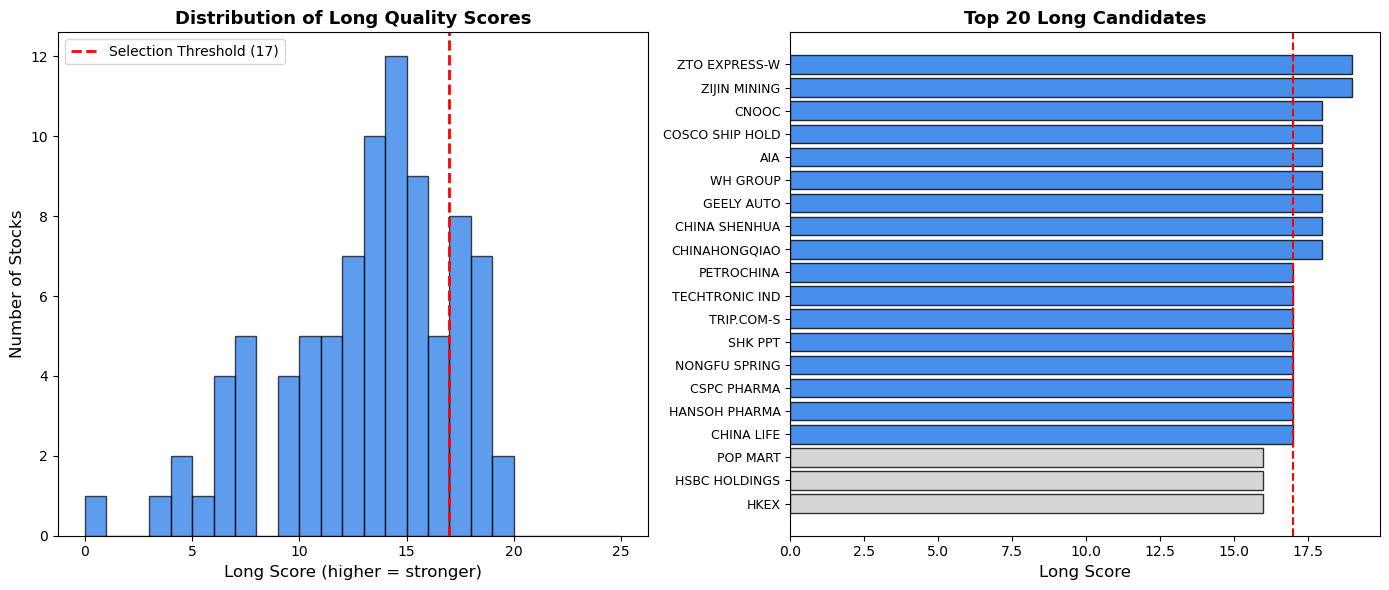

Saved: long_screening_funnel.png


In [36]:
# ============================================================
# Visualize the scoring distribution
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histogram of long scores
ax1 = axes[0]
ax1.hist(df_screen['Long_Score'], bins=range(0, 26), color='#1a73e8', alpha=0.7, edgecolor='black')
ax1.axvline(x=best_threshold, color='red', linestyle='--', linewidth=2, 
            label=f'Selection Threshold ({best_threshold})')
ax1.set_xlabel('Long Score (higher = stronger)', fontsize=12)
ax1.set_ylabel('Number of Stocks', fontsize=12)
ax1.set_title('Distribution of Long Quality Scores', fontsize=13, fontweight='bold')
ax1.legend()

# Top 20 by score
ax2 = axes[1]
top20 = df_screen_ranked.head(20)
companies = top20['Company'].apply(lambda x: str(x)[:15]).values
scores = top20['Long_Score'].values
colors = ['#1a73e8' if s >= best_threshold else '#cccccc' for s in scores]
ax2.barh(range(len(companies)-1, -1, -1), scores, color=colors, edgecolor='black', alpha=0.8)
ax2.set_yticks(range(len(companies)-1, -1, -1))
ax2.set_yticklabels(companies, fontsize=9)
ax2.set_xlabel('Long Score', fontsize=12)
ax2.set_title('Top 20 Long Candidates', fontsize=13, fontweight='bold')
ax2.axvline(x=best_threshold, color='red', linestyle='--', linewidth=1.5)

plt.tight_layout()
plt.savefig('long_screening_funnel.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: long_screening_funnel.png")

---
## 8. Final Long Book Selection

In [37]:
# ============================================================
# Select top stocks using Long Score + sector diversification
# ============================================================

MAX_SECTOR_PCT = 0.30
TARGET_LONG_COUNT = 12  # Adjust: 10-15

# Use scored and ranked candidates above threshold
df_long = df_screen_ranked[df_screen_ranked['Long_Score'] >= best_threshold].copy()

print(f"Candidates above threshold (score >= {best_threshold}): {len(df_long)}")

selected_longs = []
sector_count = {}

for idx, row in df_long.iterrows():
    sector = row.get('Sector', 'Unknown')
    current_sector_n = sector_count.get(sector, 0)
    
    # Check sector concentration
    if len(selected_longs) > 0:
        max_allowed = max(1, int(len(selected_longs) * MAX_SECTOR_PCT) + 1)
        if current_sector_n >= max_allowed and len(selected_longs) >= 5:
            continue
    
    selected_longs.append(idx)
    sector_count[sector] = current_sector_n + 1
    
    if len(selected_longs) >= TARGET_LONG_COUNT:
        break

df_final_longs = df_long.loc[selected_longs]

print(f"\n{'='*100}")
print(f"FINAL LONG BOOK — {len(df_final_longs)} STOCKS SELECTED")
print(f"{'='*100}")

final_cols = ['Company', 'Sector', 'Long_Score', 'ROE', 'PE_Trailing', 'Debt_to_Equity',
              'Dividend_Yield', 'Earnings_Growth', 'Momentum_6M_Pct',
              'Beta', 'Alpha_Annualized', 'R_Squared']
final_cols = [c for c in final_cols if c in df_final_longs.columns]

print(df_final_longs[final_cols].to_string())

print(f"\n\nSector Distribution:")
print(df_final_longs['Sector'].value_counts().to_string())

print(f"\nSignals for each pick:")
for idx, row in df_final_longs.iterrows():
    company = str(row.get('Company', idx))[:25]
    signals = row.get('Long_Signals', '')
    score = row.get('Long_Score', 0)
    print(f"  [{score:2.0f} pts] {company}: {signals}")

Candidates above threshold (score >= 17): 17

FINAL LONG BOOK — 12 STOCKS SELECTED
                 Company              Sector  Long_Score     ROE PE_Trailing Debt_to_Equity  Dividend_Yield  Earnings_Growth  Momentum_6M_Pct   Beta  Alpha_Annualized  R_Squared
Ticker                                                                                                                                                                           
2057.HK    ZTO EXPRESS-W         Industrials          19 14.2290     14.9254        17.0960        284.0000         790.7000          18.0306 0.9892            4.4174     0.3853
2899.HK     ZIJIN MINING     Basic Materials          19 29.9810     16.2765        65.9150        154.0000          76.4000          15.0489 1.0167           37.4656     0.3245
0883.HK            CNOOC              Energy          18 15.7140      9.2534         8.6690        540.0000          -4.9000          26.6167 0.5468           38.9590     0.2086
1919.HK  COSCO SHIP HOLD   

---
## 9. Long Book Visualization & Analysis

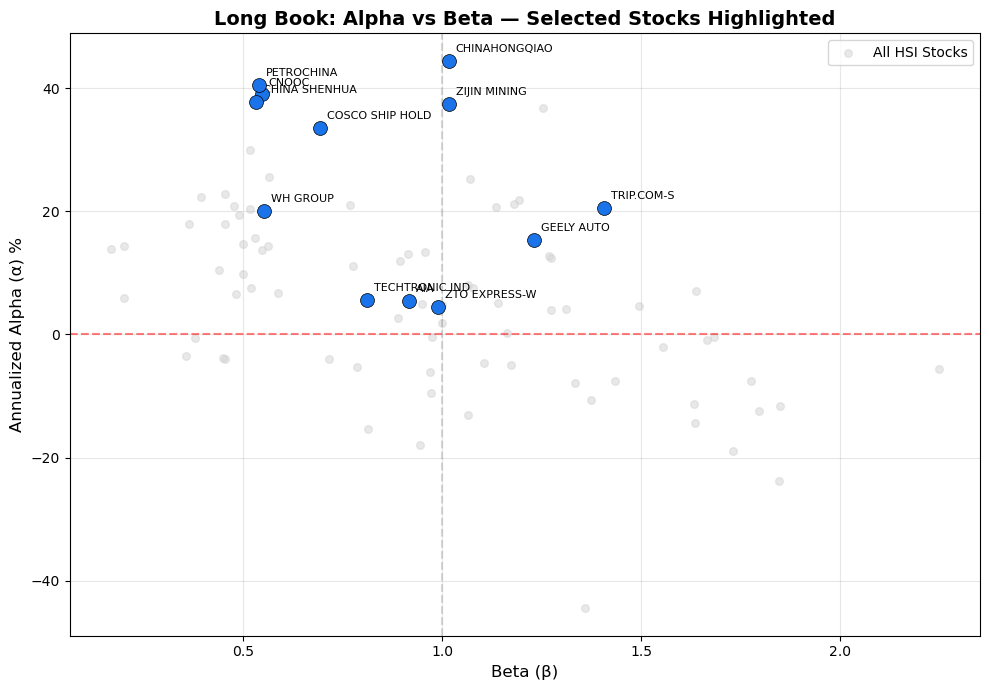

In [38]:
# ============================================================
# Chart 1: Scatter Plot — Alpha vs Beta for Long Picks
# ============================================================

fig, ax = plt.subplots(figsize=(10, 7))

# Plot all HSI stocks as background
all_with_reg = df_master.join(df_regression[['Beta', 'Alpha_Annualized', 'R_Squared']], 
                               how='inner', rsuffix='_dup')
ax.scatter(all_with_reg['Beta'], all_with_reg['Alpha_Annualized'], 
           c='lightgray', alpha=0.5, s=30, label='All HSI Stocks')

# Highlight long picks
for idx, row in df_final_longs.iterrows():
    ax.scatter(row['Beta'], row['Alpha_Annualized'], 
              c='#1a73e8', s=100, zorder=5, edgecolors='black', linewidth=0.5)
    company_name = str(row.get('Company', idx))[:15]
    ax.annotate(company_name, (row['Beta'], row['Alpha_Annualized']),
               fontsize=8, ha='left', va='bottom', xytext=(5, 5),
               textcoords='offset points')

ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.axvline(x=1, color='gray', linestyle='--', alpha=0.3)
ax.set_xlabel('Beta (β)', fontsize=12)
ax.set_ylabel('Annualized Alpha (α) %', fontsize=12)
ax.set_title('Long Book: Alpha vs Beta — Selected Stocks Highlighted', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('long_alpha_vs_beta.png', dpi=150, bbox_inches='tight')
plt.show()

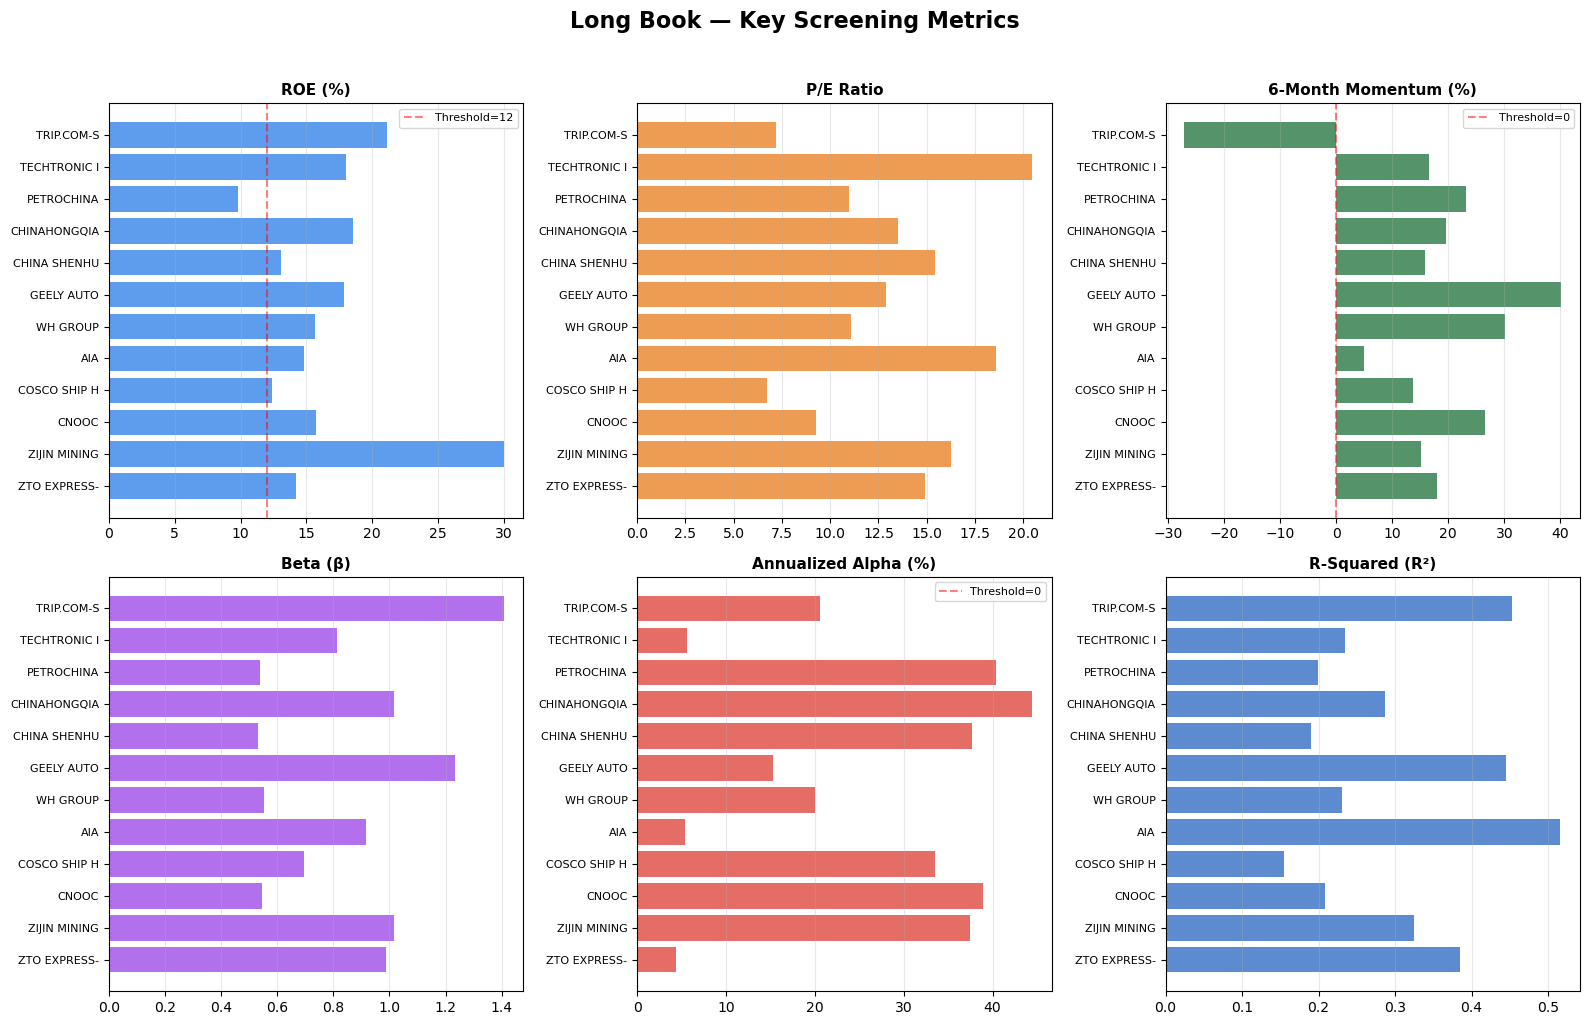

In [39]:
# ============================================================
# Chart 2: Key Metrics Comparison for Long Picks
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Long Book — Key Screening Metrics', fontsize=16, fontweight='bold', y=1.02)

metrics = [
    ('ROE', 'ROE (%)', '#1a73e8', 12),
    ('PE_Trailing', 'P/E Ratio', '#e8710a', None),
    ('Momentum_6M_Pct', '6-Month Momentum (%)', '#0d652d', 0),
    ('Beta', 'Beta (β)', '#9334e6', None),
    ('Alpha_Annualized', 'Annualized Alpha (%)', '#d93025', 0),
    ('R_Squared', 'R-Squared (R²)', '#185abc', None),
]

companies = df_final_longs['Company'].apply(lambda x: str(x)[:12]).values

for ax, (col, title, color, threshold) in zip(axes.flatten(), metrics):
    if col in df_final_longs.columns:
        values = df_final_longs[col].values
        bars = ax.barh(range(len(companies)), values, color=color, alpha=0.7)
        ax.set_yticks(range(len(companies)))
        ax.set_yticklabels(companies, fontsize=8)
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.grid(True, axis='x', alpha=0.3)
        if threshold is not None:
            ax.axvline(x=threshold, color='red', linestyle='--', alpha=0.5, label=f'Threshold={threshold}')
            ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('long_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

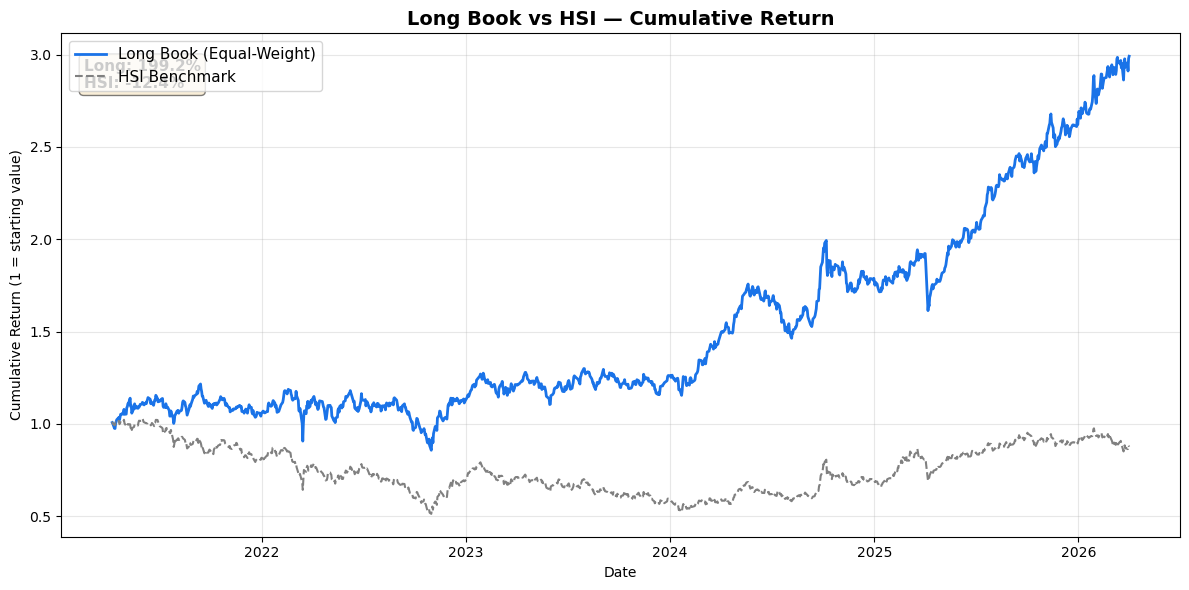

In [40]:
# ============================================================
# Chart 3: Cumulative Return — Long Picks vs HSI (Equal-Weight)
# ============================================================

long_tickers = df_final_longs.index.tolist()

# Equal-weight daily return
long_daily = daily_returns[long_tickers].mean(axis=1)
hsi_daily = daily_returns[benchmark_ticker]

# Cumulative return
long_cum = (1 + long_daily).cumprod()
hsi_cum = (1 + hsi_daily).cumprod()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(long_cum.index, long_cum.values, label='Long Book (Equal-Weight)', 
        color='#1a73e8', linewidth=2)
ax.plot(hsi_cum.index, hsi_cum.values, label='HSI Benchmark', 
        color='gray', linewidth=1.5, linestyle='--')

ax.set_title('Long Book vs HSI — Cumulative Return', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return (1 = starting value)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Add annotation
long_total = (long_cum.iloc[-1] - 1) * 100
hsi_total = (hsi_cum.iloc[-1] - 1) * 100
ax.annotate(f'Long: {long_total:.1f}%\nHSI: {hsi_total:.1f}%', 
            xy=(0.02, 0.95), xycoords='axes fraction',
            fontsize=11, fontweight='bold', va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('long_cumulative_return.png', dpi=150, bbox_inches='tight')
plt.show()

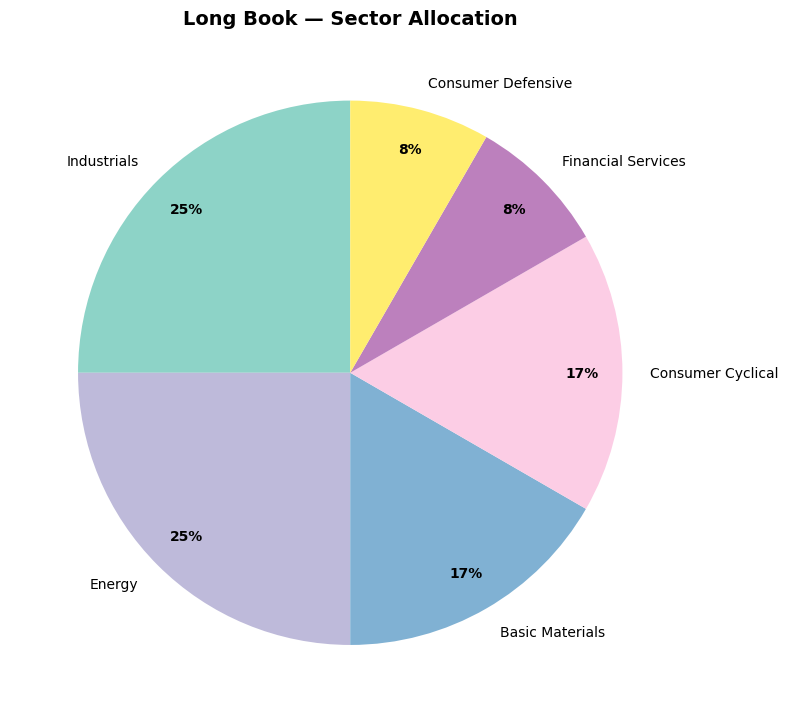

In [41]:
# ============================================================
# Chart 4: Sector Allocation Pie Chart
# ============================================================

sector_dist = df_final_longs['Sector'].value_counts()

fig, ax = plt.subplots(figsize=(8, 8))
colors = plt.cm.Set3(np.linspace(0, 1, len(sector_dist)))
wedges, texts, autotexts = ax.pie(sector_dist.values, labels=sector_dist.index,
                                   autopct='%1.0f%%', colors=colors,
                                   pctdistance=0.85, startangle=90)
for text in autotexts:
    text.set_fontweight('bold')
ax.set_title('Long Book — Sector Allocation', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('long_sector_allocation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Export Long Book Data

In [42]:
# ============================================================
# Export final long book for use in backtesting
# ============================================================

# Export selected stocks summary
export_cols = ['Company', 'Sector', 'ROE', 'PE_Trailing', 'PE_Forward',
               'Debt_to_Equity', 'Dividend_Yield', 'Earnings_Growth',
               'Momentum_6M_Pct', 'Beta', 'Alpha_Annualized', 'R_Squared',
               'Annualized_Vol_Pct', 'Long_Score']
export_cols = [c for c in export_cols if c in df_final_longs.columns]

df_final_longs[export_cols].to_csv('long_book_selected_stocks.csv')
print("Exported: long_book_selected_stocks.csv")

# Export price data for selected longs (for backtesting)
price_data[long_tickers + [benchmark_ticker]].to_csv('long_book_price_data.csv')
print("Exported: long_book_price_data.csv")

# Export full universe screening table
df_master.to_csv('hsi_full_screening_table.csv')
print("Exported: hsi_full_screening_table.csv")

print(f"\n{'='*60}")
print(f"LONG BOOK SUMMARY")
print(f"{'='*60}")
print(f"Stocks selected:     {len(df_final_longs)}")
print(f"Avg Beta:            {df_final_longs['Beta'].mean():.2f}")
print(f"Avg Alpha (ann.):    {df_final_longs['Alpha_Annualized'].mean():.2f}%")
print(f"Avg R²:              {df_final_longs['R_Squared'].mean():.2f}")
print(f"Avg ROE:             {df_final_longs['ROE'].mean():.1f}%")
print(f"Avg 6M Momentum:     {df_final_longs['Momentum_6M_Pct'].mean():.1f}%")
print(f"Sectors covered:     {df_final_longs['Sector'].nunique()}")

Exported: long_book_selected_stocks.csv
Exported: long_book_price_data.csv
Exported: hsi_full_screening_table.csv

LONG BOOK SUMMARY
Stocks selected:     12
Avg Beta:            0.85
Avg Alpha (ann.):    25.31%
Avg R²:              0.30
Avg ROE:             16.8%
Avg 6M Momentum:     16.4%
Sectors covered:     6


---
## Notes for Member B

### What to adjust:
1. **If fewer than 10 stocks pass all filters**: Relax the most restrictive criteria (try ROE > 10%, or widen Beta range)
2. **If more than 15 stocks pass**: Increase `TARGET_LONG_COUNT` or tighten criteria
3. **Data quality**: Some Yahoo Finance fields may be missing — cross-check with Bloomberg/Wind if available
4. **Important**: Verify all selected stocks are still HSI constituents at [hsi.com.hk](https://www.hsi.com.hk/eng/)

### Files generated:
- `long_book_selected_stocks.csv` — Final picks with all metrics (share with Member E for backtesting)
- `long_book_price_data.csv` — Historical prices (share with Member E)
- `hsi_full_screening_table.csv` — Full universe data
- `long_screening_funnel.png` — Funnel chart for presentation
- `long_alpha_vs_beta.png` — Alpha vs Beta scatter for presentation
- `long_metrics_comparison.png` — Metrics bar charts
- `long_cumulative_return.png` — Performance vs benchmark
- `long_sector_allocation.png` — Sector pie chart